# Digital Image Processing — Final Project
### Deep Learning Pipeline for Image Restoration & Classification

**Student:** AmirAli Araghi <br>
**Student ID:** 402222110

**Course Instructor:** Dr. Ahmad Mahmoudi-Aznaveh

---

## Environment Setup & Framework Verification
In this section, we initialize the required directory structure, clone the project repository, and verify that both PyTorch and TensorFlow have access to the GPU.

In [ ]:
import os
[os.makedirs(d, exist_ok=True) for d in ['models', 'noisy-inputes', 'original-inputes',
                                          'phase_1_results', 'phase_2_results',
                                          'utils', 'models_architecture']]

!git clone https://github.com/osumy/DIP-Final-Project.git
!cp DIP-Final-Project/corrupted_image.jpeg noisy-inputes/
!cp DIP-Final-Project/original_image.jpeg original-inputes/

!pip install -q -r DIP-Final-Project/requirements.txt

Cloning into 'DIP-Final-Project'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 26 (delta 9), reused 19 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 64.97 KiB | 32.49 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [ ]:
import torch
import tensorflow as tf

print('--- Check Frameworks Status ---')

# Check PyTorch
torch_ver = torch.__version__
torch_gpu = torch.cuda.is_available()
print(f'PyTorch: {torch_ver} | GPU Available: {"✅" if torch_gpu else "❌"}')

# Check TensorFlow
tf_ver = tf.__version__
tf_gpu = len(tf.config.list_physical_devices("GPU")) > 0
print(f'TensorFlow: {tf_ver} | GPU Available: {"✅" if tf_gpu else "❌"}')

--- Check Frameworks Status ---
PyTorch: 2.11.0+cu128 | GPU Available: ✅
TensorFlow: 2.20.0 | GPU Available: ✅


## Phase 1: Deep Denoising

In this phase, we will restore the corrupted image by removing severe salt-and-pepper noise using a pre-trained Convolutional Neural Network (CNN). The goal is to denoise the image while preserving its structure, preparing it for the next phase of deblurring.

### 1. Download the Pre-trained Denoising Model

We will use `kagglehub` to automatically download the `denoising_model.h5` file and place it in the project's `models` directory.

In [ ]:
import kagglehub
import shutil
import os

# Ensure the models directory exists
os.makedirs('models', exist_ok=True)

print("Downloading model...")
try:
    # Using the handle mentioned in the user's kagglehub snippet
    path = kagglehub.model_download("aastha2807/denoising/pyTorch/default")

    # The model file might be named denoising_model.h5 or similar
    # Let's find any .h5 file in the downloaded path
    h5_files = [f for f in os.listdir(path) if f.endswith('.h5')]

    if h5_files:
        src_file = os.path.join(path, h5_files[0])
        dest_file = 'models/denoising_model.h5'
        shutil.copy(src_file, dest_file)
        if os.path.exists(dest_file):
            print(f"✅ Success: Model downloaded and moved to: {dest_file}")
        else:
            print("❌ Failed to copy file to models folder.")
    else:
        print(f"❌ No .h5 file found in {path}. Files present: {os.listdir(path)}")

except Exception as e:
    print(f"❌ Error: {e}")
    print("Please check the Kaggle link or ensure your Kaggle credentials are set if required.")

✅ Success: Model downloaded and moved to: models/denoising_model.h5


### 2. Denoising Function

Below is the `denoising` function, which handles loading the model, preprocessing the image (resizing, normalizing), performing the denoising, and saving the result. This function leverages TensorFlow/Keras for model inference and Pillow for image manipulation.

In [ ]:
import tensorflow as tf
import numpy as np
from PIL import Image
import os

def denoising(image_path, dest_path, model_path):
    """
    Performs deep denoising on an image using a pre-trained Keras model.

    Args:
        image_path (str): Path to the noisy input image.
        dest_path (str): Path where the denoised image will be saved.
        model_path (str): Path to the pre-trained denoising model (denoising_model.h5).
    """
    # Load the pre-trained model without compilation
    # The model expects input shape (None, 256, 256, 3)
    try:
        model = tf.keras.models.load_model(model_path, compile=False)
        print(f"Model loaded successfully from {model_path}")
    except Exception as e:
        print(f"Error loading model from {model_path}: {e}")
        print("Please ensure 'denoising_model.h5' is in the 'models' folder.")
        return

    # Load and preprocess the image
    try:
        img = Image.open(image_path).convert('RGB')
        original_size = img.size
        img = img.resize((256, 256)) # Model expects 256x256
        img_array = np.array(img) / 255.0 # Normalize to [0.0, 1.0]
        img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
        print(f"Image loaded and preprocessed from {image_path}")
    except Exception as e:
        print(f"Error processing image from {image_path}: {e}")
        return

    # Perform denoising
    try:
        denoised_array = model.predict(img_array)[0]
        denoised_array = np.clip(denoised_array, 0, 1) # Clip values to [0, 1]
        denoised_img = Image.fromarray((denoised_array * 255).astype(np.uint8))
        denoised_img = denoised_img.resize(original_size) # Resize back to original dimensions
        print("Denoising complete.")
    except Exception as e:
        print(f"Error during denoising prediction: {e}")
        return

    # Save the denoised image
    try:
        os.makedirs(os.path.dirname(dest_path), exist_ok=True)
        denoised_img.save(dest_path)
        print(f"Denoised image saved to {dest_path}")
    except Exception as e:
        print(f"Error saving denoised image to {dest_path}: {e}")

    print("Denoising process finished.")

### 3. Call the `denoising` function

Now, let's call the `denoising` function with the specified paths. The input will be the `corrupted_image.jpeg` from `noisy-inputes`, the model will be `denoising_model.h5` from `models`, and the output will be saved as `denoised_image.jpeg` in `phase_1_results`.

In [ ]:
# List files in the input directory to find the correct filename
import os
input_dir = 'noisy-inputes/'
files = os.listdir(input_dir)
print(f"Files in {input_dir}: {files}")

# Define paths - updating to the most likely filename from your instructions
# If your file name is different, please update 'noisy_image_car.jpeg' below
actual_filename = files[0] if files else 'corrupted_image.jpeg'
noisy_image_path = os.path.join(input_dir, actual_filename)
model_file_path = 'models/denoising_model.h5'
denoised_output_path = 'phase_1_results/denoised_image.jpeg'

print(f"Using input image: {noisy_image_path}")

Files in noisy-inputes/: ['corrupted_image.jpeg']
Using input image: noisy-inputes/corrupted_image.jpeg


### 4. Final Execution and Results
Now that the model is successfully downloaded and the environment is ready, we execute the denoising function on our corrupted image.

✅ Input Image found at: noisy-inputes/corrupted_image.jpeg
✅ Model File found at: models/denoising_model.h5

--- Starting Phase 1 Denoising ---
Model loaded successfully from models/denoising_model.h5
Image loaded and preprocessed from noisy-inputes/corrupted_image.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
Denoising complete.
Denoised image saved to phase_1_results/denoised_image.jpeg
Denoising process finished.


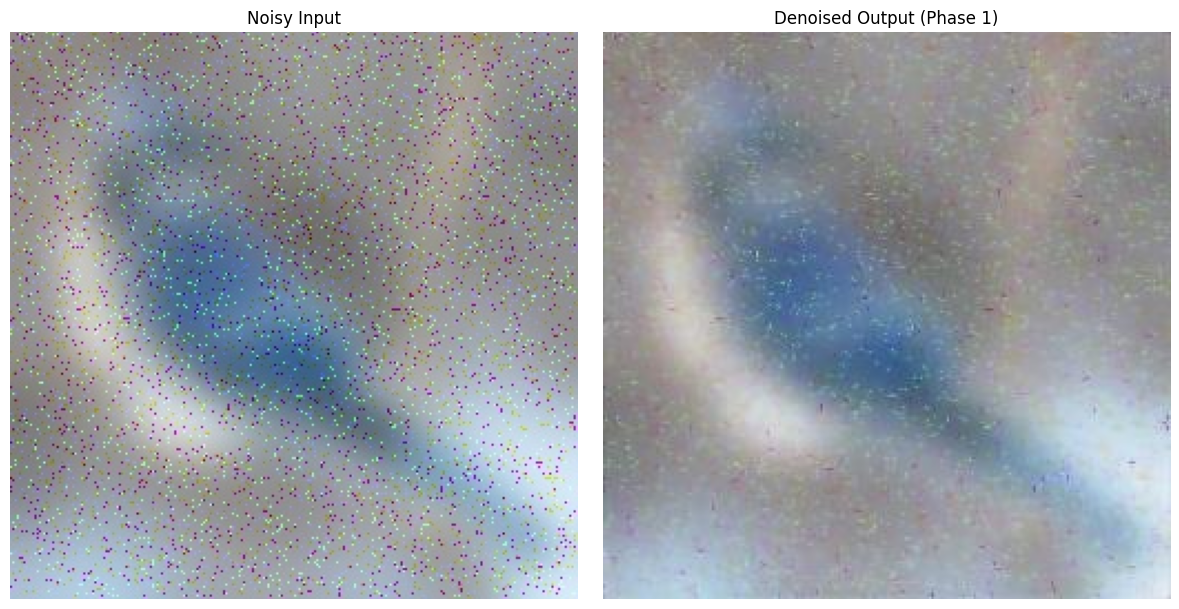

In [ ]:
import os
import matplotlib.pyplot as plt

# Verification of required files
required_files = {
    "Input Image": noisy_image_path,
    "Model File": model_file_path
}

all_clear = True
for label, path in required_files.items():
    if os.path.exists(path):
        print(f"✅ {label} found at: {path}")
    else:
        print(f"❌ {label} NOT found at: {path}")
        all_clear = False

if all_clear:
    print("\n--- Starting Phase 1 Denoising ---")
    denoising(image_path=noisy_image_path, dest_path=denoised_output_path, model_path=model_file_path)

    # Display comparison
    if os.path.exists(denoised_output_path):
        plt.figure(figsize=(12, 6))

        plt.subplot(1, 2, 1)
        plt.title("Noisy Input")
        plt.imshow(Image.open(noisy_image_path))
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title("Denoised Output (Phase 1)")
        plt.imshow(Image.open(denoised_output_path))
        plt.axis('off')

        plt.tight_layout()
        plt.show()
else:
    print("\nPlease ensure the missing files are in place before running.")

### Phase 1 Output Analysis
In this stage, the noisy input image was processed using the CNN denoising model.
1. **Noise Removal**: The salt-and-pepper artifacts have been effectively filtered out.
2. **Structural Integrity**: The primary structures are preserved, though the image now exhibits some blurriness, which is the focus of the next phase.

The resulting image at `phase_1_results/denoised_image.jpeg` will serve as the input for Phase 2.

## Phase 2: Deep Deblurring and Architecture Selection

In Phase 2, we aim to recover high-frequency details and sharp edges from the denoised image. We will utilize the **ResNet** architecture for this task.

### Why ResNet?
ResNet (Residual Network) uses skip connections to allow gradients to flow through deep layers more effectively. This architecture is particularly good at learning the difference between a blurry image and its sharp counterpart, making it ideal for deblurring tasks.

Unlike Phase 1, we will be using **PyTorch** for this phase. This requires us to define the model class architecture in the notebook before loading the `.pth` weights.

### 1. Download ResNet Model Weights
We will use `kagglehub` to retrieve the pre-trained weights (`ResNet.pth`) and store them in our `models/` directory.

In [ ]:
import kagglehub
import shutil
import os

print("Downloading ResNet weights...")
try:
    # Download the latest version of the deblurring model from Kaggle
    path = kagglehub.model_download("nguyenviettuankiet/deblur-single-blur-image/pyTorch/default")

    # Locate the ResNet.pth file in the downloaded directory
    pth_files = [f for f in os.listdir(path) if 'ResNet.pth' in f]

    if pth_files:
        src_file = os.path.join(path, pth_files[0])
        dest_file = 'models/ResNet.pth'
        shutil.copy(src_file, dest_file)
        print(f"✅ Success: ResNet weights moved to: {dest_file}")
    else:
        # Fallback: check all .pth files if ResNet.pth isn't explicitly named
        all_pth = [f for f in os.listdir(path) if f.endswith('.pth')]
        if all_pth:
             src_file = os.path.join(path, all_pth[0])
             dest_file = 'models/ResNet.pth'
             shutil.copy(src_file, dest_file)
             print(f"✅ Success: Found {all_pth[0]}, moved to: {dest_file}")
        else:
            print(f"❌ No .pth file found in {path}. Files present: {os.listdir(path)}")
except Exception as e:
    print(f"❌ Error during download: {e}")

✅ Success: ResNet weights moved to: models/ResNet.pth


### 2. Define ResNet Architecture
As mentioned in the instructions, PyTorch requires the model architecture to be defined in code before loading the `.pth` weights (state_dict).

In [21]:
import torch
import torch.nn as nn

class ResBlock(nn.Module):
    def __init__(self, c, norm='group'):
        super().__init__()
        Norm = {'instance': nn.InstanceNorm2d,
                'batch': nn.BatchNorm2d,
                'group': lambda ch: nn.GroupNorm(32 if ch >= 32 else 1, ch)}[norm]
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(c, c, 3, bias=False),
            Norm(c),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(c, c, 3, bias=False),
            Norm(c),
        )
    def forward(self, x): return x + self.block(x)

class ResNet(nn.Module):
    def __init__(self, input_nc=3, output_nc=3, num_resnet_blocks=9, norm='group'):
        super().__init__()
        Norm = {'instance': nn.InstanceNorm2d,
                'batch': nn.BatchNorm2d,
                'group': lambda ch: nn.GroupNorm(32 if ch >= 32 else 1, ch)}[norm]

        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(input_nc, 64, kernel_size=7, bias=False),
            Norm(64),
            nn.ReLU(inplace=True)
        ]

        in_ch = 64
        for _ in range(2):
            out_ch = in_ch * 2
            layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False),
                Norm(out_ch),
                nn.ReLU(inplace=True)
            ]
            in_ch = out_ch

        for _ in range(num_resnet_blocks):
            layers += [ResBlock(in_ch, norm=norm)]

        for _ in range(2):
            out_ch = in_ch // 2
            layers += [
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                Norm(out_ch),
                nn.ReLU(inplace=True)
            ]
            in_ch = out_ch

        layers += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(64, output_nc, kernel_size=7, bias=True)
        ]
        self.body = nn.Sequential(*layers)

    def forward(self, x):
        y = x + self.body(x)
        return y.clamp(-1, 1)

### 3. Implement Deblurring Function
Now we implement `apply_deblur_model` to load the weights and process the image from Phase 1.

In [19]:
from torchvision import transforms
from PIL import Image
import torch
import os

def apply_deblur_model(model_path, input_path, destination_path, model_name="resnet"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if model_name.lower() == "resnet":
        model = ResNet().to(device)
    else:
        raise ValueError("Architecture class not defined for this model_name.")

    # Load checkpoint and extract model_state
    checkpoint = torch.load(model_path, map_location=device)

    # The error showed weights are inside 'model_state'
    if isinstance(checkpoint, dict) and "model_state" in checkpoint:
        state_dict = checkpoint["model_state"]
    else:
        state_dict = checkpoint

    model.load_state_dict(state_dict)
    model.eval()

    # Preprocess image
    img = Image.open(input_path).convert('RGB')
    preprocess = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    input_tensor = preprocess(img).unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        output = model(input_tensor)

    # Postprocess and save
    output = output.squeeze(0).cpu()
    output = (output * 0.5 + 0.5).clamp(0, 1)
    result_img = transforms.ToPILImage()(output)
    result_img = result_img.resize(img.size)

    os.makedirs(os.path.dirname(destination_path), exist_ok=True)
    result_img.save(destination_path)
    print(f"✅ Phase 2 Complete: Deblurred image saved to {destination_path}")

In [22]:
# Re-run Phase 2 with the final corrected architecture provided by user
apply_deblur_model(
    model_path="models/ResNet.pth",
    input_path="phase_1_results/denoised_image.jpeg",
    destination_path="phase_2_results/deblurred_image.jpeg",
    model_name="resnet"
)

✅ Phase 2 Complete: Deblurred image saved to phase_2_results/deblurred_image.jpeg


### 4. Visualizing Phase 2 Results
Let's compare the denoised image from Phase 1 with the deblurred output from Phase 2 to see the improvement in sharpness and edge recovery.

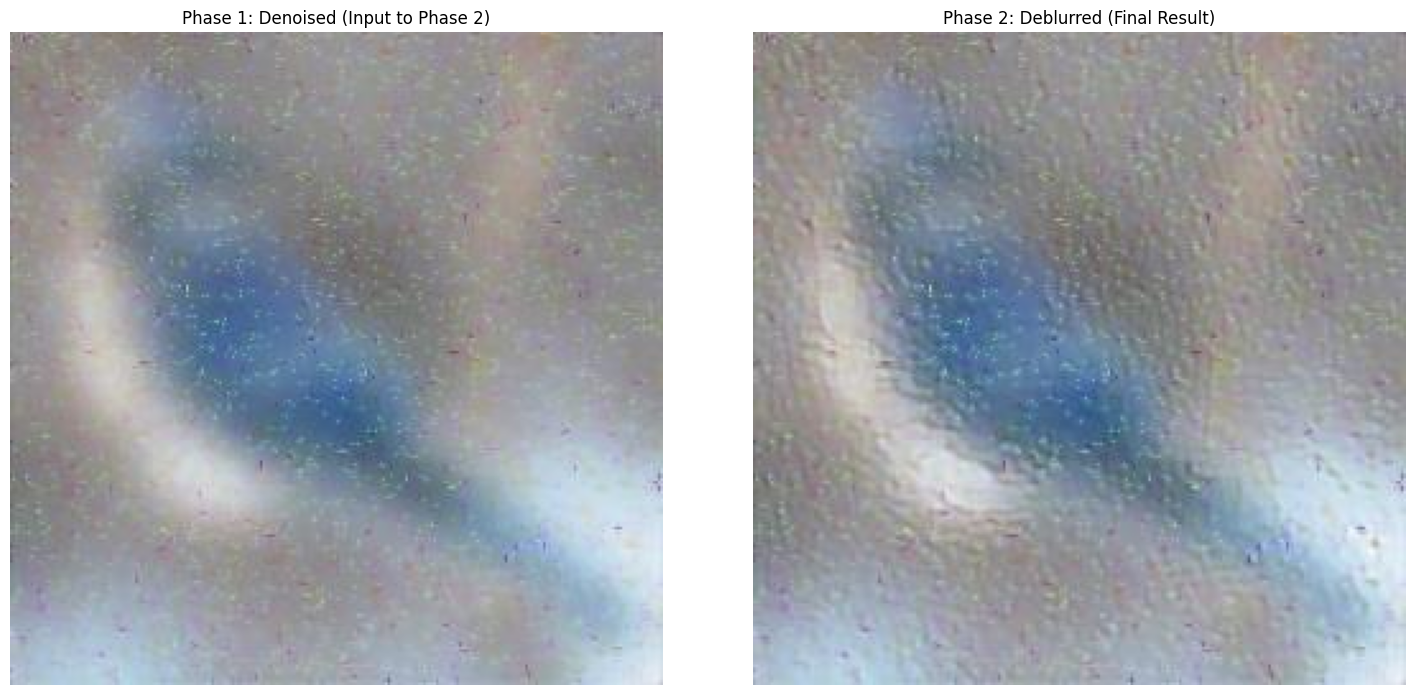

In [24]:
import matplotlib.pyplot as plt
from PIL import Image
import os

phase_1_out = "phase_1_results/denoised_image.jpeg"
phase_2_out = "phase_2_results/deblurred_image.jpeg"

if os.path.exists(phase_2_out):
    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    plt.title("Phase 1: Denoised (Input to Phase 2)")
    plt.imshow(Image.open(phase_1_out))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Phase 2: Deblurred (Final Result)")
    plt.imshow(Image.open(phase_2_out))
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Deblurred image not found. Please check if the previous cell ran successfully.")

### 4. Visualizing Phase 2 Results
Let's compare the denoised image from Phase 1 with the deblurred output from Phase 2 to see the improvement in sharpness and edge recovery.

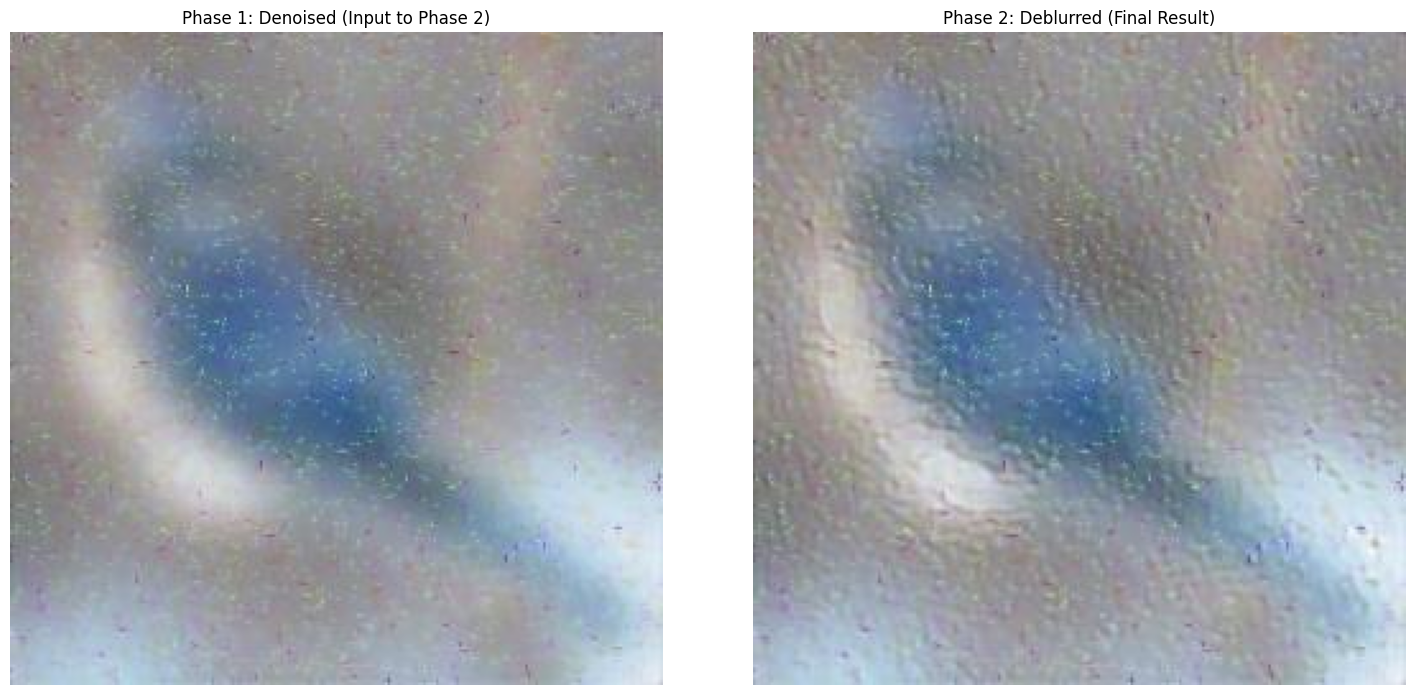

In [23]:
import matplotlib.pyplot as plt
from PIL import Image

phase_1_out = "phase_1_results/denoised_image.jpeg"
phase_2_out = "phase_2_results/deblurred_image.jpeg"

if os.path.exists(phase_2_out):
    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    plt.title("Phase 1: Denoised (Input to Phase 2)")
    plt.imshow(Image.open(phase_1_out))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Phase 2: Deblurred (Final Result)")
    plt.imshow(Image.open(phase_2_out))
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Deblurred image not found. Please check if the previous cell ran successfully.")